# 02. Exploratory Data Analysis (EDA)

## Overview
In this notebook, we explore the IBM Telco Customer Churn dataset to uncover key patterns, risk factors, and behavioral drivers associated with customer attrition.

### Analysis Goals:
1. **Class Balance Inspection**: Understand the baseline churn distribution (~26.5% positive class).
2. **Demographics vs Churn**: Analyze senior citizens, partners, and dependents.
3. **Contract and Financial Drivers**: Evaluate contract duration (month-to-month vs annual), payment methods, and monthly charges.
4. **Service Usage Patterns**: Examine internet service type (fiber optic vs DSL) and add-on services.
5. **Continuous Feature Distributions**: Visualize tenure and billing distributions for churned vs retained customers.


### Library Setup and Plotting Configurations
We configure matplotlib and seaborn for consistent visualization styling across all figures.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set project root path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

print("Setup complete")

Setup complete


### Load Cleaned Dataset
We load `cleaned_data.csv` generated in notebook 01.

In [2]:
df = pd.read_csv(DATA_DIR / "cleaned_data.csv")
print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(3)

Loaded dataset: 7043 rows, 29 columns


,CustomerID,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Total Charges,Churn Value,Avg Monthly Charges,Charges Per Tenure,Tenure Band,High Monthly Charges,Long Tenure,Multiple Services,Has Phone,Has Internet
0,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,108.15,1,54.0750,17.950000,0-12,0,0,2,1,1
1,9237-HQITU,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,151.65,1,75.8250,23.566667,0-12,1,0,0,1,1
2,9305-CDSKC,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,820.50,1,102.5625,11.072222,0-12,1,0,3,1,1


### Class Balance Inspection
We analyze the distribution of the target variable `Churn Value` (0 = Retained, 1 = Churned). Severe class imbalance requires evaluation metrics beyond simple accuracy (such as PR-AUC and F1-Score).

              Count  Percentage (%)
Retained (0)   5174           73.46
Churned (1)    1869           26.54


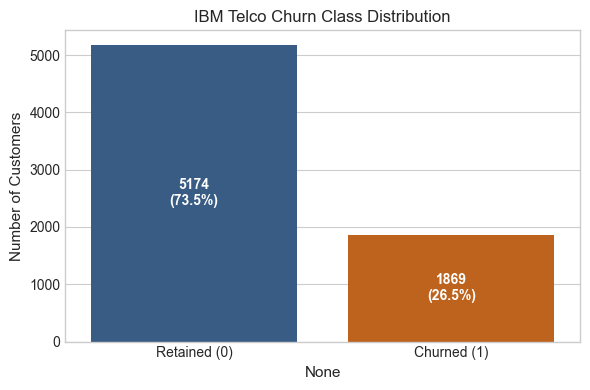

In [3]:
churn_counts = df['Churn Value'].value_counts()
churn_percentages = df['Churn Value'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Count': churn_counts,
    'Percentage (%)': churn_percentages.round(2)
})
summary_df.index = ['Retained (0)', 'Churned (1)']
print(summary_df)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=summary_df.index, y=summary_df['Count'], hue=summary_df.index, palette=['steelblue', 'darkorange'], legend=False, ax=ax)
ax.set_title("IBM Telco Churn Class Distribution")
ax.set_ylabel("Number of Customers")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}\n({p.get_height()/len(df):.1%})", 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2), 
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_class_distribution.png", dpi=150)
plt.show()

### Demographic Risk Factors
We investigate churn rates across demographic groups: Senior Citizens, Partner status, and Dependents.

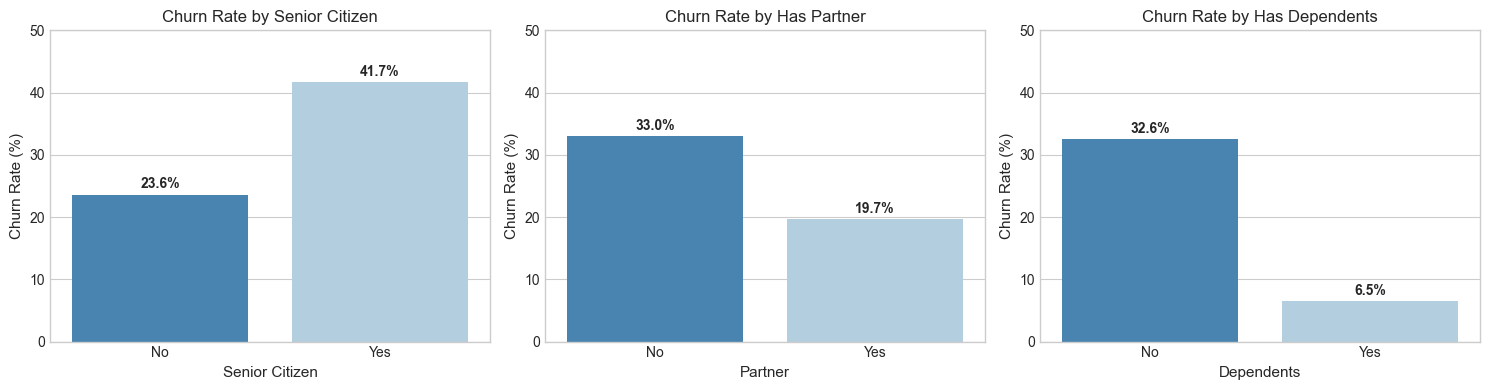

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

demo_cols = ['Senior Citizen', 'Partner', 'Dependents']
titles = ['Senior Citizen', 'Has Partner', 'Has Dependents']

for idx, col in enumerate(demo_cols):
    rate = df.groupby(col)['Churn Value'].mean() * 100
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index, ax=axes[idx], palette='Blues_r', legend=False)
    axes[idx].set_title(f"Churn Rate by {titles[idx]}")
    axes[idx].set_ylabel("Churn Rate (%)")
    axes[idx].set_ylim(0, 50)
    for p in axes[idx].patches:
        axes[idx].annotate(f"{p.get_height():.1f}%", 
                           (p.get_x() + p.get_width() / 2., p.get_height() + 1), 
                           ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_demographics_churn.png", dpi=150)
plt.show()

### Contract Type and Billing Method
Contract type is typically one of the strongest predictors of churn. We compare Month-to-month contracts against 1-Year and 2-Year contracts, as well as payment methods.

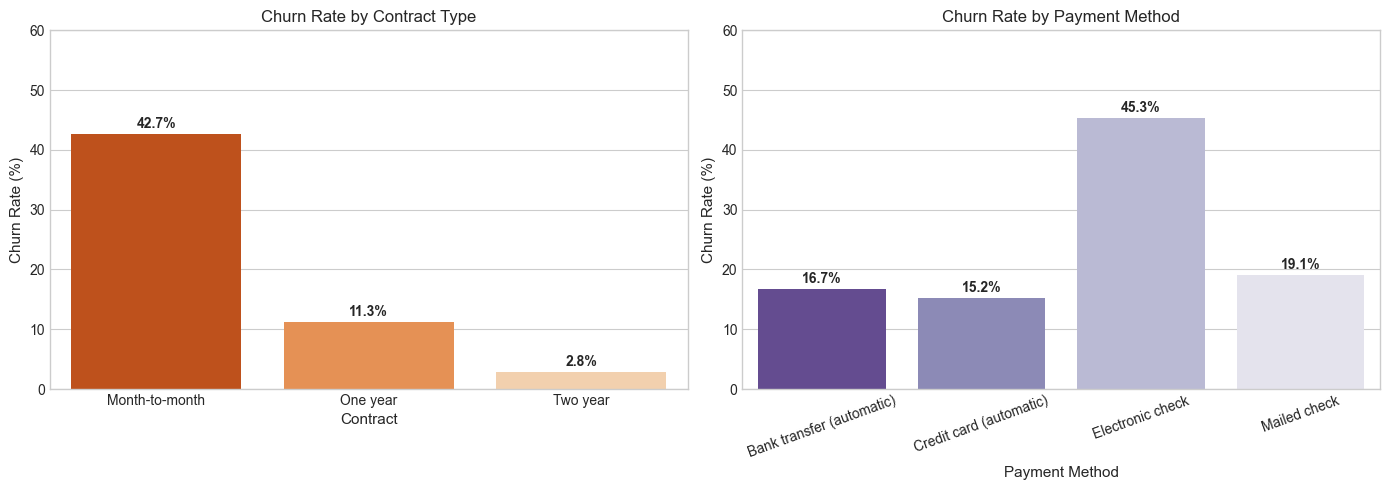

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contract Type
contract_churn = df.groupby('Contract')['Churn Value'].mean().reset_index()
contract_churn['Churn Rate (%)'] = contract_churn['Churn Value'] * 100
sns.barplot(data=contract_churn, x='Contract', y='Churn Rate (%)', hue='Contract', ax=axes[0], palette='Oranges_r', legend=False)
axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_ylim(0, 60)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha='center', fontweight='bold')

# Payment Method
payment_churn = df.groupby('Payment Method')['Churn Value'].mean().reset_index()
payment_churn['Churn Rate (%)'] = payment_churn['Churn Value'] * 100
sns.barplot(data=payment_churn, x='Payment Method', y='Churn Rate (%)', hue='Payment Method', ax=axes[1], palette='Purples_r', legend=False)
axes[1].set_title("Churn Rate by Payment Method")
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0, 60)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_contract_payment.png", dpi=150)
plt.show()

### Internet Service and Add-On Services
Customers with Fiber Optic internet service exhibit significantly higher churn rates compared to DSL or No Internet service. Furthermore, customers with multiple add-on security/support services churn less.

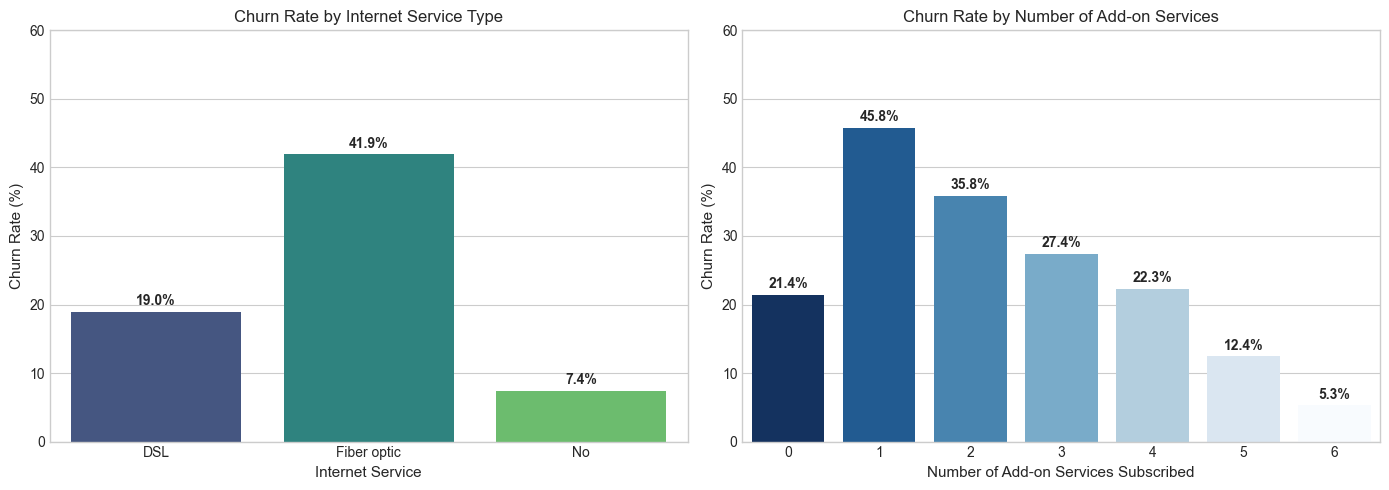

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Internet Service
net_churn = df.groupby('Internet Service')['Churn Value'].mean().reset_index()
net_churn['Churn Rate (%)'] = net_churn['Churn Value'] * 100
sns.barplot(data=net_churn, x='Internet Service', y='Churn Rate (%)', hue='Internet Service', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title("Churn Rate by Internet Service Type")
axes[0].set_ylim(0, 60)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha='center', fontweight='bold')

# Multiple Services Count
services_churn = df.groupby('Multiple Services')['Churn Value'].mean().reset_index()
services_churn['Churn Rate (%)'] = services_churn['Churn Value'] * 100
sns.barplot(data=services_churn, x='Multiple Services', y='Churn Rate (%)', hue='Multiple Services', ax=axes[1], palette='Blues_r', legend=False)
axes[1].set_title("Churn Rate by Number of Add-on Services")
axes[1].set_xlabel("Number of Add-on Services Subscribed")
axes[1].set_ylim(0, 60)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_services.png", dpi=150)
plt.show()


### Continuous Feature Distributions (Tenure & Charges)
We analyze the distribution of `Tenure Months` and `Monthly Charges` split by churn status.

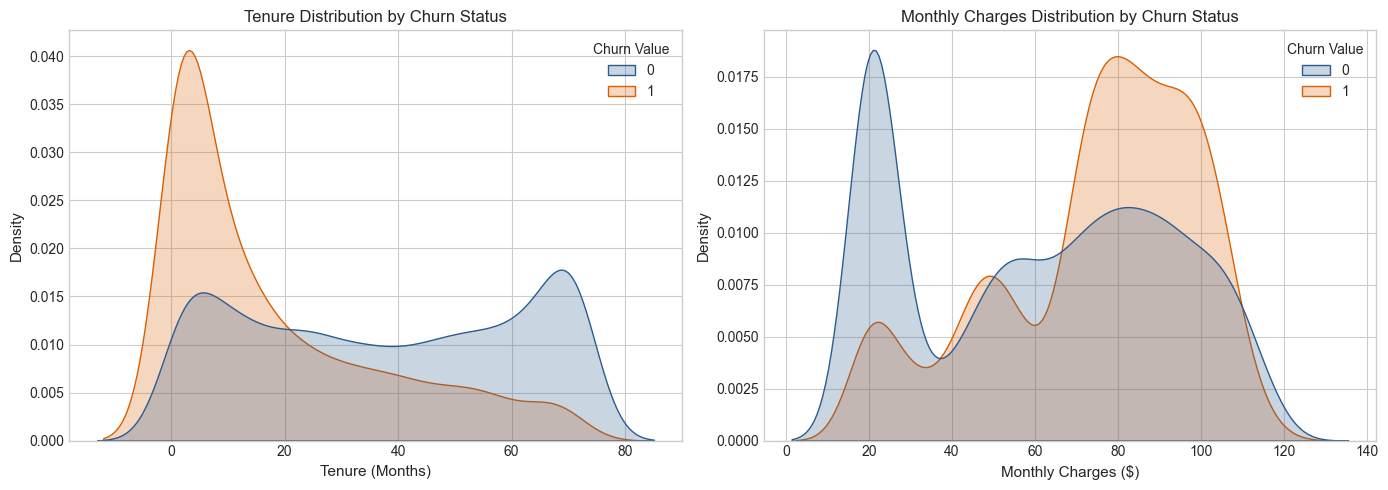

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure Months Distribution
sns.kdeplot(data=df, x='Tenure Months', hue='Churn Value', common_norm=False, fill=True, palette=['steelblue', 'darkorange'], ax=axes[0])
axes[0].set_title("Tenure Distribution by Churn Status")
axes[0].set_xlabel("Tenure (Months)")

# Monthly Charges Distribution
sns.kdeplot(data=df, x='Monthly Charges', hue='Churn Value', common_norm=False, fill=True, palette=['steelblue', 'darkorange'], ax=axes[1])
axes[1].set_title("Monthly Charges Distribution by Churn Status")
axes[1].set_xlabel("Monthly Charges ($)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_tenure_charges_dist.png", dpi=150)
plt.show()

### Summary of Key EDA Findings

1. **High-Risk Profile**: Customers on **Month-to-month contracts** (42% churn), with **Fiber optic internet** (41% churn), paying via **Electronic check** (45% churn), and with short tenure (0-12 months).
2. **Low-Risk Profile**: Long-tenure customers (>24 months) on 2-year contracts (<3% churn), subscribing to multiple online security/support add-on services.
3. **Class Imbalance**: Baseline churn rate is 26%, confirming the need for stratified cross-validation and imbalance-aware pipeline modeling in **Notebook 03**.
